In [1]:
import os
import kagglehub
import pandas as pd

# 1. Download the full suite via kagglehub
path = kagglehub.dataset_download("sgpjesus/bank-account-fraud-dataset-neurips-2022")
print("Dataset downloaded to:", path)

# 2. List the available variant files in the directory
files = os.listdir(path)
print("\nAvailable files in suite:")
for f in files:
    if f.endswith('.csv'):
        print(f" - {f}")

# 3. Load the Base dataset to start modeling
# (Change the filename to test out the drift variants like 'Variant_1.csv', etc.)
base_df_path = os.path.join(path, "Base.csv")
df = pd.read_csv(base_df_path)

print(f"\nSuccessfully loaded Base dataset: {df.shape[0]} rows, {df.shape[1]} columns.")

100%|██████████| 532M/532M [00:26<00:00, 21.0MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022/versions/2

Available files in suite:
 - Variant I.csv
 - Variant II.csv
 - Variant III.csv
 - Base.csv
 - Variant IV.csv
 - Variant V.csv

Successfully loaded Base dataset: 1000000 rows, 32 columns.


In [2]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


Once Google Drive is mounted, we'll create a new folder within your specified Google Drive location to save the dataset files. Then, we will copy all the CSV files from the downloaded KaggleHub directory to this new Google Drive folder.

In [3]:
# Define the Google Drive destination path using the folder ID provided by the user
google_drive_folder_id = '1RX6ITF-659nNwXSLWl3wDPZ3OG1N4Ziz'
google_drive_base_path = f'/content/drive/MyDrive/'
destination_path = os.path.join(google_drive_base_path, 'Bank_Account_Fraud_Dataset')

# Create the destination directory if it doesn't exist
os.makedirs(destination_path, exist_ok=True)
print(f"Created or ensured existence of destination folder: {destination_path}")

# Copy all .csv files from the KaggleHub download path to the Google Drive destination
for f in files:
    if f.endswith('.csv'):
        source_file = os.path.join(path, f)
        destination_file = os.path.join(destination_path, f)
        shutil.copy(source_file, destination_file)
        print(f"Copied '{f}' to '{destination_path}'")

print("\nAll .csv files have been successfully copied to Google Drive.")

Created or ensured existence of destination folder: /content/drive/MyDrive/Bank_Account_Fraud_Dataset
Copied 'Variant I.csv' to '/content/drive/MyDrive/Bank_Account_Fraud_Dataset'
Copied 'Variant II.csv' to '/content/drive/MyDrive/Bank_Account_Fraud_Dataset'
Copied 'Variant III.csv' to '/content/drive/MyDrive/Bank_Account_Fraud_Dataset'
Copied 'Base.csv' to '/content/drive/MyDrive/Bank_Account_Fraud_Dataset'
Copied 'Variant IV.csv' to '/content/drive/MyDrive/Bank_Account_Fraud_Dataset'
Copied 'Variant V.csv' to '/content/drive/MyDrive/Bank_Account_Fraud_Dataset'

All .csv files have been successfully copied to Google Drive.


Now that the data is loaded into a pandas DataFrame, let's perform some descriptive analysis. We'll start by looking at the summary statistics of numerical columns using `df.describe()` and then check the DataFrame's information (data types, non-null counts) using `df.info()`.

In [4]:
print("\nDescriptive statistics for numerical columns:")
display(df.describe())


Descriptive statistics for numerical columns:


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.000000
mean,0.011029,0.562696,0.493694,16.718568,86.587867,33.689080,1.025705e+00,8.661499,1572.692049,5665.296605,...,0.889676,10.839303,0.222988,515.851010,0.025242,7.544940,0.576947,1.018312,0.0,3.288674
std,0.104438,0.290343,0.289125,44.046230,88.406599,12.025799,5.381835e+00,20.236155,1005.374565,3009.380665,...,0.313293,12.116875,0.416251,487.559902,0.156859,8.033106,0.494044,0.180761,0.0,2.209994
min,0.000000,0.100000,0.000001,-1.000000,-1.000000,10.000000,4.036860e-09,-15.530555,1.000000,-170.603072,...,0.000000,-1.000000,0.000000,190.000000,0.000000,-1.000000,0.000000,-1.000000,0.0,0.000000
25%,0.000000,0.300000,0.225216,-1.000000,19.000000,20.000000,7.193246e-03,-1.181488,894.000000,3436.365848,...,1.000000,-1.000000,0.000000,200.000000,0.000000,3.103053,0.000000,1.000000,0.0,1.000000
50%,0.000000,0.600000,0.492153,-1.000000,52.000000,30.000000,1.517574e-02,-0.830507,1263.000000,5319.769349,...,1.000000,5.000000,0.000000,200.000000,0.000000,5.114321,1.000000,1.000000,0.0,3.000000
75%,0.000000,0.800000,0.755567,12.000000,130.000000,40.000000,2.633069e-02,4.984176,1944.000000,7680.717827,...,1.000000,25.000000,0.000000,500.000000,0.000000,8.866131,1.000000,1.000000,0.0,5.000000
max,1.000000,0.900000,0.999999,383.000000,428.000000,90.000000,7.845690e+01,112.956928,6700.000000,16715.565404,...,1.000000,32.000000,1.000000,2100.000000,1.000000,85.899143,1.000000,2.000000,0.0,7.000000


In [5]:
print("\nDataFrame Information (data types, non-null counts):")
display(df.info())


DataFrame Information (data types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-nul

None

From the `df.info()` output, we can see several `object` type columns, which are likely categorical. Let's list these columns and then proceed with one-hot encoding them for model preparation.

In [6]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns: {list(categorical_cols)}")

# Perform one-hot encoding on categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nDataFrame after one-hot encoding:")
display(df_encoded.head())

Categorical columns: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

DataFrame after one-hot encoding:


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,housing_status_BC,housing_status_BD,housing_status_BE,housing_status_BF,housing_status_BG,source_TELEAPP,device_os_macintosh,device_os_other,device_os_windows,device_os_x11
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,1059,13096.035018,...,True,False,False,False,False,False,False,False,False,False
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,1658,9223.283431,...,True,False,False,False,False,False,False,True,False,False
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,1095,4471.472149,...,True,False,False,False,False,False,False,False,True,False
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,3483,14431.993621,...,True,False,False,False,False,False,False,False,False,False
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,2339,7601.511579,...,True,False,False,False,False,False,False,True,False,False


Now that the categorical variables are encoded, we can prepare the data for a predictive model. We'll separate the features (X) from the target variable (`fraud_bool`, y) and then split the data into training and testing sets.

In [7]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('fraud_bool', axis=1)
y = df_encoded['fraud_bool']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (700000, 47)
X_test shape: (300000, 47)
y_train shape: (700000,)
y_test shape: (300000,)


Now that our data is prepared, let's train a classification model. We'll use `LogisticRegression` from `sklearn` as a baseline. To address the class imbalance (as `fraud_bool` has a low proportion of fraudulent cases), we'll set `class_weight='balanced'`.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import numpy as np

# Initialize and train the Logistic Regression model with balanced class weights
# Increased max_iter for convergence on larger datasets
model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC AUC Score:", roc_auc_score(y_test, y_pred_proba))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=['Actual No Fraud', 'Actual Fraud'], columns=['Predicted No Fraud', 'Predicted Fraud']))

# To identify which variables are most influential in predicting fraud, we can look at the coefficients.
# For Logistic Regression, larger absolute coefficient values indicate stronger influence.
print("\nTop 10 most influential features (by absolute coefficient value):")
feature_importance = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_[0]})
feature_importance['abs_coefficient'] = np.abs(feature_importance['coefficient'])
top_features = feature_importance.sort_values(by='abs_coefficient', ascending=False).head(10)
display(top_features)

Logistic Regression model trained successfully.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89    296691
           1       0.04      0.80      0.08      3309

    accuracy                           0.80    300000
   macro avg       0.52      0.80      0.49    300000
weighted avg       0.99      0.80      0.88    300000


ROC AUC Score: 0.8762464957759802

Confusion Matrix:


,Predicted No Fraud,Predicted Fraud
Actual No Fraud,238564,58127
Actual Fraud,669,2640



Top 10 most influential features (by absolute coefficient value):


,feature,coefficient,abs_coefficient
41,housing_status_BG,-2.752872,2.752872
39,housing_status_BE,-1.453312,1.453312
40,housing_status_BF,-1.312384,1.312384
18,has_other_cards,-1.307692,1.307692
36,housing_status_BB,-1.284038,1.284038
45,device_os_windows,1.282421,1.282421
37,housing_status_BC,-1.227803,1.227803
1,name_email_similarity,-1.212636,1.212636
34,employment_status_CF,-0.966587,0.966587
15,phone_home_valid,-0.952918,0.952918


Now that our data is prepared, let's train a classification model. We'll use `LogisticRegression` from `sklearn` as a baseline. To address the class imbalance (as `fraud_bool` has a low proportion of fraudulent cases), we'll set `class_weight='balanced'`.

In [9]:
import os
import kagglehub
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np

# --- Start of added code to ensure df and df_encoded are defined ---
# 1. Download the full suite via kagglehub (assuming it might be needed again)
path = kagglehub.dataset_download("sgpjesus/bank-account-fraud-dataset-neurips-2022")
# 3. Load the Base dataset to start modeling
base_df_path = os.path.join(path, "Base.csv")
df = pd.read_csv(base_df_path)

# Identify categorical columns and perform one-hot encoding
categorical_cols = df.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
# --- End of added code ---

# Define features (X) and target (y)
X = df_encoded.drop('fraud_bool', axis=1)
y = df_encoded['fraud_bool']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize and train the Logistic Regression model with balanced class weights
# Increased max_iter for convergence on larger datasets
model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC AUC Score:", roc_auc_score(y_test, y_pred_proba))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=['Actual No Fraud', 'Actual Fraud'], columns=['Predicted No Fraud', 'Predicted Fraud']))

# To identify which variables are most influential in predicting fraud, we can look at the coefficients.
# For Logistic Regression, larger absolute coefficient values indicate stronger influence.
print("\nTop 10 most influential features (by absolute coefficient value):")
feature_importance = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_[0]})
feature_importance['abs_coefficient'] = np.abs(feature_importance['coefficient'])
top_features = feature_importance.sort_values(by='abs_coefficient', ascending=False).head(10)
display(top_features)

Using Colab cache for faster access to the 'bank-account-fraud-dataset-neurips-2022' dataset.
Logistic Regression model trained successfully.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89    296691
           1       0.04      0.80      0.08      3309

    accuracy                           0.80    300000
   macro avg       0.52      0.80      0.49    300000
weighted avg       0.99      0.80      0.88    300000


ROC AUC Score: 0.8762464957759802

Confusion Matrix:


,Predicted No Fraud,Predicted Fraud
Actual No Fraud,238564,58127
Actual Fraud,669,2640



Top 10 most influential features (by absolute coefficient value):


,feature,coefficient,abs_coefficient
41,housing_status_BG,-2.752872,2.752872
39,housing_status_BE,-1.453312,1.453312
40,housing_status_BF,-1.312384,1.312384
18,has_other_cards,-1.307692,1.307692
36,housing_status_BB,-1.284038,1.284038
45,device_os_windows,1.282421,1.282421
37,housing_status_BC,-1.227803,1.227803
1,name_email_similarity,-1.212636,1.212636
34,employment_status_CF,-0.966587,0.966587
15,phone_home_valid,-0.952918,0.952918


In [10]:
display(top_features)

,feature,coefficient,abs_coefficient
41,housing_status_BG,-2.752872,2.752872
39,housing_status_BE,-1.453312,1.453312
40,housing_status_BF,-1.312384,1.312384
18,has_other_cards,-1.307692,1.307692
36,housing_status_BB,-1.284038,1.284038
45,device_os_windows,1.282421,1.282421
37,housing_status_BC,-1.227803,1.227803
1,name_email_similarity,-1.212636,1.212636
34,employment_status_CF,-0.966587,0.966587
15,phone_home_valid,-0.952918,0.952918


/tmp/ipykernel_700/3229275552.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='abs_coefficient', y='feature', data=top_features, palette='viridis')


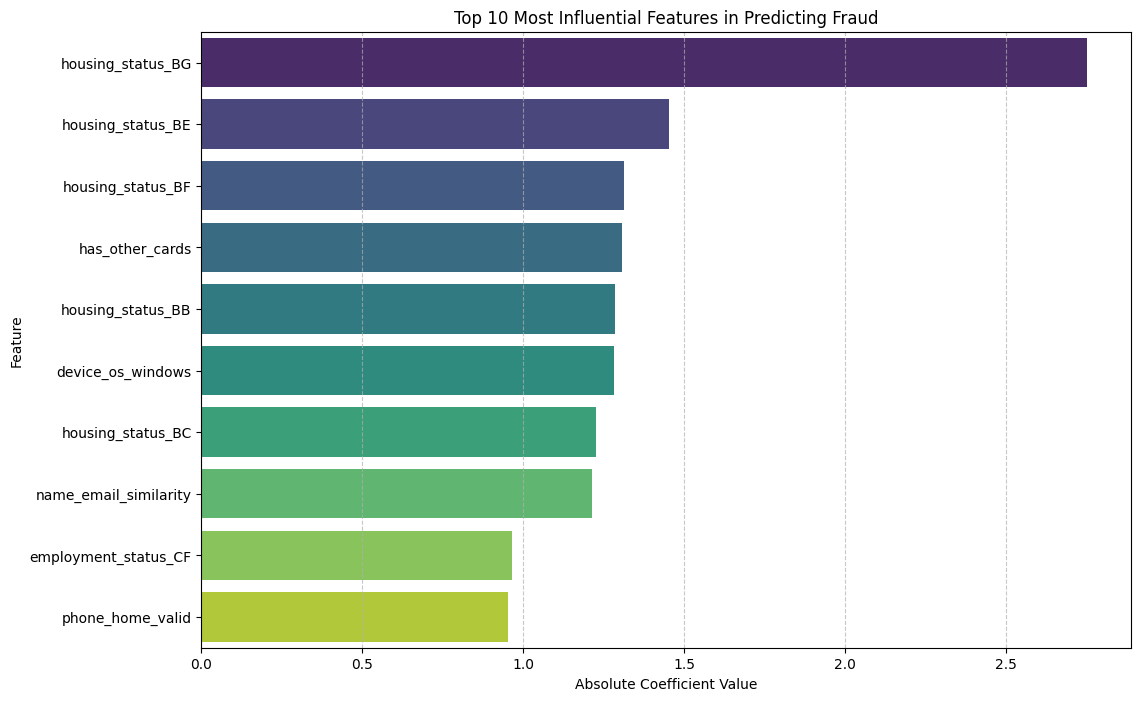

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import os
import kagglehub

# --- Ensure df is defined ---
# This section assumes the original df loading cell (dtbX2P17KVSp) has defined 'path'.
# If 'df' is not already defined, it will be re-loaded here.
if 'df' not in locals():
    print("Reloading df and related variables...")
    # Re-download dataset path if not available
    try:
        path = kagglehub.dataset_download("sgpjesus/bank-account-fraud-dataset-neurips-2022")
    except NameError: # If kagglehub is not defined in path's context
        import kagglehub
        path = kagglehub.dataset_download("sgpjesus/bank-account-fraud-dataset-neurips-2022")

    base_df_path = os.path.join(path, "Base.csv")
    df = pd.read_csv(base_df_path)

    # Identify categorical columns and perform one-hot encoding
    categorical_cols = df.select_dtypes(include='object').columns
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # Define features (X) and target (y)
    X = df_encoded.drop('fraud_bool', axis=1)
    y = df_encoded['fraud_bool']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Initialize and train the Logistic Regression model with balanced class weights
    model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=1000)
    model.fit(X_train, y_train)

    print("df, X, y, X_train, y_train, model have been re-defined.")

# --- If df is already defined but X or model are not, ensure they are setup ---
# This handles cases where df is present but downstream processing wasn't completed
if 'X' not in locals() or 'model' not in locals():
    print("Defining X, y, X_train, y_train, and model from existing df...")
    categorical_cols = df.select_dtypes(include='object').columns
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    X = df_encoded.drop('fraud_bool', axis=1)
    y = df_encoded['fraud_bool']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=1000)
    model.fit(X_train, y_train)
    print("X, y, X_train, y_train, model have been defined.")

# Recalculate top_features to ensure it's defined and up-to-date for plotting
feature_importance = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_[0]})
feature_importance['abs_coefficient'] = np.abs(feature_importance['coefficient'])
top_features = feature_importance.sort_values(by='abs_coefficient', ascending=False).head(10)

# Create a horizontal bar chart of the top features
plt.figure(figsize=(12, 8))
sns.barplot(x='abs_coefficient', y='feature', data=top_features, palette='viridis')
plt.title('Top 10 Most Influential Features in Predicting Fraud')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [12]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Initialize and train the LightGBM model
# Using is_unbalance=True to handle imbalanced classes
lgbm_model = lgb.LGBMClassifier(random_state=42, is_unbalance=True)
lgbm_model.fit(X_train, y_train)

print("LightGBM model trained successfully.")

# Make predictions on the test set
y_pred_lgbm = lgbm_model.predict(X_test)
y_pred_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

# Evaluate the LightGBM model
print("\nLightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgbm))

print("\nLightGBM ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_lgbm))

print("\nLightGBM Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_lgbm), index=['Actual No Fraud', 'Actual Fraud'], columns=['Predicted No Fraud', 'Predicted Fraud']))

[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.128554 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3230
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176
LightGBM model trained successfully.

LightGBM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.90    296691
           1       0.05      0.77      0.09      3309

    accuracy                           0.83    300000
   macro avg       0.52      0.80      0.50    300000
weighted avg       0.99      0.83      0.90    300000


LightGBM ROC AUC Score: 0.8802154205940378


,Predicted No Fraud,Predicted Fraud
Actual No Fraud,245478,51213
Actual Fraud,764,2545


In [13]:
# Install Optuna if not already installed
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 27.6 MB/s eta 0:00:00


In [14]:
import optuna
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

def objective(trial):
    # Define the hyperparameters to tune
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 0.1, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 0.1, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'is_unbalance': True # Keep this for imbalanced data
    }

    # Train the LightGBM model
    model = lgb.LGBMClassifier(**param)
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              eval_metric='auc',
              callbacks=[lgb.early_stopping(100, verbose=False)]) # Early stopping to prevent overfitting

    # Make predictions and calculate ROC AUC score
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)

    return auc_score

print("Objective function for Optuna defined.")

Objective function for Optuna defined.


In [ ]:
# Create an Optuna study and optimize it
# You can increase n_trials for a more thorough search, but it will take longer.
study = optuna.create_study(direction='maximize', study_name='lgbm_tuning')
study.optimize(objective, n_trials=50) # Reduced n_trials for faster execution in a notebook example

print("Number of finished trials:", len(study.trials))
print("Best trial:", study.best_trial.value)

print("Best hyperparameters:")
best_params = study.best_trial.params
for key, value in best_params.items():
    print(f"  {key}: {value}")

[I 2026-07-24 07:00:57,176] A new study created in memory with name: lgbm_tuning


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.098846 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3230
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-07-24 07:02:07,304] Trial 0 finished with value: 0.8857062463136827 and parameters: {'n_estimators': 500, 'learning_rate': 0.08455122294856743, 'num_leaves': 26, 'max_depth': 20, 'min_child_samples': 85, 'subsample': 0.9432948201446429, 'colsample_bytree': 0.9724874398465417, 'reg_alpha': 0.04932907093485212, 'reg_lambda': 0.003552306526487362}. Best is trial 0 with value: 0.8857062463136827.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.098032 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3230
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-07-24 07:02:26,178] Trial 1 finished with value: 0.8814506121997783 and parameters: {'n_estimators': 100, 'learning_rate': 0.07339099959532015, 'num_leaves': 24, 'max_depth': 14, 'min_child_samples': 98, 'subsample': 0.8003873442827368, 'colsample_bytree': 0.9755881424192908, 'reg_alpha': 0.009017748191701615, 'reg_lambda': 0.05443081725122623}. Best is trial 0 with value: 0.8857062463136827.


...

[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.094502 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3230
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-07-24 07:29:47,974] Trial 18 finished with value: 0.8967137373115053 and parameters: {'n_estimators': 800, 'learning_rate': 0.010002647079790278, 'num_leaves': 39, 'max_depth': 7, 'min_child_samples': 48, 'subsample': 0.8897377959053154, 'colsample_bytree': 0.7197417083842924, 'reg_alpha': 0.003834577882388818, 'reg_lambda': 0.004445040206385573}. Best is trial 10 with value: 0.8969501120273917.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.097417 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3230
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-07-24 07:31:34,432] Trial 19 finished with value: 0.8939229529452378 and parameters: {'n_estimators': 600, 'learning_rate': 0.02304560525015674, 'num_leaves': 75, 'max_depth': 11, 'min_child_samples': 28, 'subsample': 0.7191561652351961, 'colsample_bytree': 0.8945198101852211, 'reg_alpha': 0.09526066262372646, 'reg_lambda': 0.012495679857055715}. Best is trial 10 with value: 0.8969501120273917.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.098739 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3230
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

After optimizing the LightGBM hyperparameters using Optuna, let's evaluate the performance of the best model on the test set. We will look at the **Classification Report**, **ROC AUC Score**, and **Confusion Matrix** to understand its effectiveness in predicting fraudulent transactions.

*   **Classification Report**: Provides precision, recall, f1-score, and support for each class. It's especially useful for imbalanced datasets.
*   **ROC AUC Score**: Measures the ability of the model to distinguish between classes. A higher score (closer to 1.0) indicates better performance.
*   **Confusion Matrix**: A table that describes the performance of a classification model. It shows the counts of true positive, true negative, false positive, and false negative predictions.

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import pandas as pd

# Train a new LightGBM model with the best hyperparameters found by Optuna
best_lgbm_model = lgb.LGBMClassifier(**best_params, random_state=42, n_jobs=-1, is_unbalance=True)
best_lgbm_model.fit(X_train, y_train)

print("LightGBM model trained with best hyperparameters successfully.")

# Make predictions on the test set with the best model
y_pred_lgbm_tuned = best_lgbm_model.predict(X_test)
y_pred_proba_lgbm_tuned = best_lgbm_model.predict_proba(X_test)[:, 1]

# Evaluate the tuned LightGBM model
print("\nLightGBM Tuned Classification Report:")
print(classification_report(y_test, y_pred_lgbm_tuned))

print("\nLightGBM Tuned ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_lgbm_tuned))

print("\nLightGBM Tuned Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_lgbm_tuned), index=['Actual No Fraud', 'Actual Fraud'], columns=['Predicted No Fraud', 'Predicted Fraud']))

In [1]:
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import os
import kagglehub

# This block ensures that the necessary variables are available in case of a kernel restart
# or out-of-order execution, making the cell robust.
if 'y_test' not in locals() or 'model' not in locals() or 'best_lgbm_model' not in locals():
    print("Detected missing variables. Re-initializing data and models for comparison...")

    # Re-load data and perform preprocessing
    if 'df' not in locals():
        print("  `df` not found, reloading from KaggleHub.")
        try:
            # Attempt to use existing `path` if defined (from dtbX2P17KVSp)
            if 'path' not in locals():
                path = kagglehub.dataset_download("sgpjesus/bank-account-fraud-dataset-neurips-2022")
            base_df_path = os.path.join(path, "Base.csv")
            df = pd.read_csv(base_df_path)
        except (NameError, Exception):
            # Fallback for fresh kernel or path not defined
            print("  KaggleHub path not found, downloading dataset...")
            path = kagglehub.dataset_download("sgpjesus/bank-account-fraud-dataset-neurips-2022")
            base_df_path = os.path.join(path, "Base.csv")
            df = pd.read_csv(base_df_path)

    if 'df_encoded' not in locals():
        print("  `df_encoded` not found, re-encoding categorical columns.")
        categorical_cols = df.select_dtypes(include='object').columns
        df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    if 'X_test' not in locals() or 'y_test' not in locals():
        print("  `X_test` or `y_test` not found, re-splitting data.")
        X = df_encoded.drop('fraud_bool', axis=1)
        y = df_encoded['fraud_bool']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Re-train Logistic Regression model if 'model' is not available
    if 'model' not in locals():
        print("  Logistic Regression model not found, re-training.")
        model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=1000)
        model.fit(X_train, y_train)

    # Re-train LightGBM model with best hyperparameters if 'best_lgbm_model' is not available
    if 'best_lgbm_model' not in locals():
        print("  Tuned LightGBM model not found, attempting to re-train with stored or default params.")
        if 'best_params' not in locals():
            print("    `best_params` from Optuna not found. Using default parameters for LightGBM.")
            # Using default/fallback parameters if Optuna's best_params are not in scope
            best_params = {
                'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31,
                'max_depth': -1, 'min_child_samples': 20, 'subsample': 1.0,
                'colsample_bytree': 1.0, 'reg_alpha': 0.0, 'reg_lambda': 0.0,
                'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt'
            }
        best_lgbm_model = lgb.LGBMClassifier(**best_params, random_state=42, n_jobs=-1, is_unbalance=True)
        best_lgbm_model.fit(X_train, y_train)
        print("  Tuned LightGBM model re-trained.")

    print("Re-initialization complete.")

print(f"Baseline Logistic Regression ROC AUC Score: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")
print(f"Tuned LightGBM ROC AUC Score: {roc_auc_score(y_test, best_lgbm_model.predict_proba(X_test)[:, 1]):.4f}")

Detected missing variables. Re-initializing data and models for comparison...
  `df` not found, reloading from KaggleHub.
Using Colab cache for faster access to the 'bank-account-fraud-dataset-neurips-2022' dataset.
  `df_encoded` not found, re-encoding categorical columns.
  `X_test` or `y_test` not found, re-splitting data.
  Logistic Regression model not found, re-training.
  Tuned LightGBM model not found, attempting to re-train with stored or default params.
    `best_params` from Optuna not found. Using default parameters for LightGBM.
[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.122295 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3230
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 46
[LightGBM] [Info] [binary:B